# Performance comparison by means of scatter plots

It is a head to head comparison of the results for the same implied bitmask, across all families and a threshold in the number of resources.

In [59]:
!pwd

/Users/wilberquito/repos/mspsp-all/mspsp-stats/notebooks/smtapi/by-time


In [60]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent
print(ROOT)

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

# Set working directory to the notebook's location

pprint(DIRS)

/Users/wilberquito/repos/mspsp-all/mspsp-stats
{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/figures/smtapi')}


In [61]:
os.listdir(DIRS["data"]["wandb"])

['smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=0__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=1__pb_like=0.csv',
 'smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=1__

In [62]:
instances_description_csv = f"{DIRS['data']['analysis']}/mspsp_stats.csv"
instances_description_df = pd.read_csv(instances_description_csv)
instances_description_df.shape

(1142, 10)

In [63]:
instances_description_df.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.0671,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.0671,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...


In [64]:
wandb_dir = DIRS["data"]["wandb"]

df_wandb = pd.concat(
    [
        pd.read_csv(os.path.join(wandb_dir, f))
        for f in os.listdir(wandb_dir)
        if f.endswith(".csv")
    ],
    ignore_index=True,
)
df_wandb.shape

(27408, 22)

In [65]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(lambda x: np.log10(x))
    return df


def add_family_column(df: pd.DataFrame) -> pd.DataFrame:
    df["family"] = df["mspsp_instance"].apply(lambda x: x.split("/")[-2])
    return df


df_wandb = add_implied_column(df_wandb, check=True)
df_wandb = add_logarithmic_time(df_wandb)
df_wandb = add_family_column(df_wandb)

In [66]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family'],
      dtype='object')

In [67]:
df_wandb.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,model,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time,pb_like,implied_bitmask,solver.log_real_time,family
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:29; S_2:0; S_3:0; S_4:9; S_5:12; ...,False,OPTIMUM_FOUND,0.33,0.00,0.25,NaN,0100,-0.481486,set-1a
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:10; S_2:0; S_3:0; S_4:10; S_5:28;...,False,OPTIMUM_FOUND,0.11,0.01,0.10,NaN,0100,-0.958607,set-1a


In [68]:
# Filter configurations
implied_config_filter = ["0001"]

df_wandb = df_wandb[~df_wandb["implied_bitmask"].isin(implied_config_filter)]
df_wandb.shape

(22840, 25)

In [69]:
# Rename exactpb to exact
df_wandb["solver"] = df_wandb["solver"].replace({"exactpb": "exact"})
df_wandb["solver"].unique()

array(['evalmaxsat', 'maxcdcl', 'exact', 'roundingsat'], dtype=object)

In [70]:
# Rename the inline config that contains exactpb to exact

df_wandb["inline_config"] = df_wandb["inline_config"].str.replace(
    "exactpb", "exact", regex=False
)
df_wandb["inline_config"].unique()

array(['f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0',
       'f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0',
       'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0',
       'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0',
       'f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0',
       'f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0',
       'f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0',
       'f=opb__s=exact__i=i1=0,i2=0,i3=1,i4=0__pb_like=0',
       'f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0',
       'f=opb__s=exact__i=i1=0,i2=0,i3=0,i4=0__pb_like=0',
       'f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0',
       'f=opb__s=exact__i=i1=1,i2=1,i3=0,i4=0__pb_like=0',
       'f=opb__s=roundingsat__i=i1=0,i2=0,i3=1,i4=0__pb_like=0',
       'f=opb__s=exact__i=i1=1,i2=0,i3=0,i4=0__pb_like=0',
       'f=opb__s=roundingsat__i=i1=0,i2=1,i3=0,i4=0__pb_like=0',
       'f=opb__s=exact__i=i1=0,i2=1,i3=0,i4=0__pb_like=0',
       'f=opb__s=roundingsat__i=i1=1,i2=0,i3=0,i4=0__pb_like=0',
   

In [71]:
experiments_df = (
    df_wandb[["inline_config", "implied_bitmask"]]
    .drop_duplicates()
    .sort_values("inline_config")
    .reset_index(drop=True)
)
experiments_df

,inline_config,implied_bitmask
0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0",0000
1,"f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=1,i4=0",0010
2,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",0100
3,"f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0",1000
4,"f=maxsat__s=evalmaxsat__i=i1=1,i2=1,i3=0,i4=0",1100
5,"f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0",0000
6,"f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0",0010
7,"f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0",0100
8,"f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0",1000
9,"f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0",1100


In [72]:
n = len(experiments_df["inline_config"].values)


pairs = [
    (
        (
            experiments_df["inline_config"].values[i],
            experiments_df["inline_config"].values[j],
        ),
        experiments_df["implied_bitmask"].values[i],
    )
    for i in range(n)
    for j in range(i + 1, n)
    if experiments_df["implied_bitmask"].values[i]
    == experiments_df["implied_bitmask"].values[j]
]

len(pairs)

30

In [73]:
pairs[:5]

[(('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=opb__s=exact__i=i1=0,i2=0,i3=0,i4=0__pb_like=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0',
   'f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0'),
  '0000'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=1,i4=0',
   'f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0'),
  '0010'),
 (('f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=1,i4=0',
   'f=opb__s=exact__i=i1=0,i2=0,i3=1,i4=0__pb_like=0'),
  '0010')]

In [74]:
# Merge the wandb data with the instance descriptions to get family information
df_merged = pd.merge(
    df_wandb,
    instances_description_df[["mspsp_instance", "n_activities"]],
    on="mspsp_instance",
    how="inner",
)

df_merged.shape

(22840, 26)

In [75]:
df_merged.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time,pb_like,implied_bitmask,solver.log_real_time,family,n_activities
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,False,OPTIMUM_FOUND,0.33,0.00,0.25,NaN,0100,-0.481486,set-1a,22
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,False,OPTIMUM_FOUND,0.11,0.01,0.10,NaN,0100,-0.958607,set-1a,22


In [76]:
# Compute the median of activities
median_activities = df_merged["n_activities"].median()
median_activities = int(median_activities)
print(f"Median number of activities: {median_activities}")

Median number of activities: 42


This generates the different scatter plots comparing the performance of the different solvers. The main goal is to compare the performance of OPBVSMaxSAT with EvalMaxSAT-Exact, but we can also compare with other solvers if we want to.

In [77]:
def metadata_name(experiment_name: str, trim: int = 3) -> dict:
    parts = dict(item.split("=", 1) for item in experiment_name.split("__"))

    solver = parts["s"]
    implied = [item.split("=")[1] for item in parts["i"].split(",")][:trim]
    implied = "".join(implied)

    metadata = {
        "axis": f"{solver} ({implied})",
        "solver": solver,
        "implied": implied,
    }

    return metadata

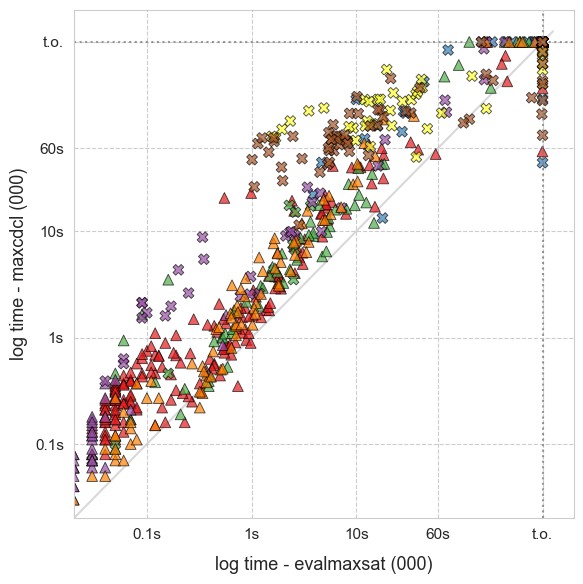

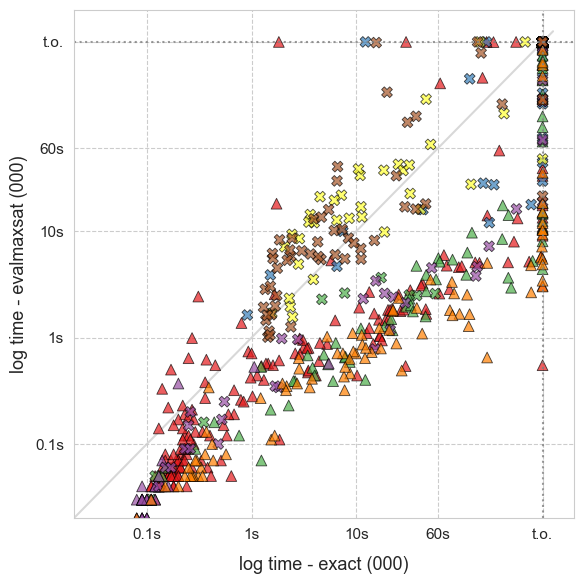

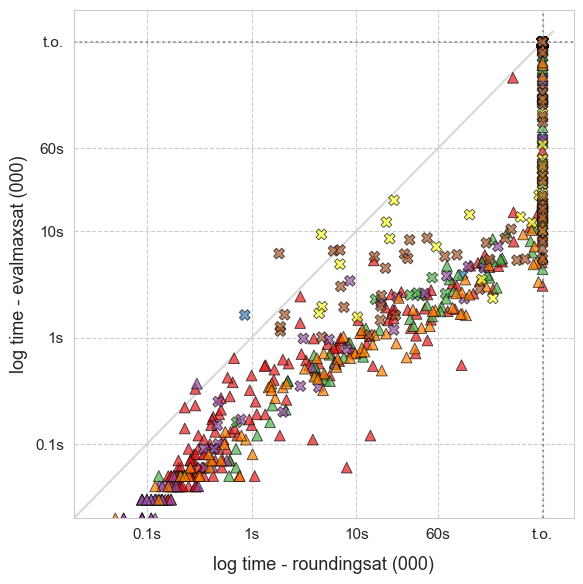

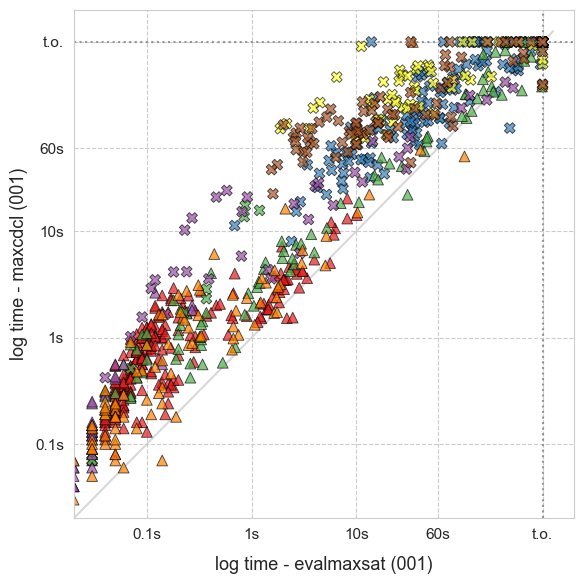

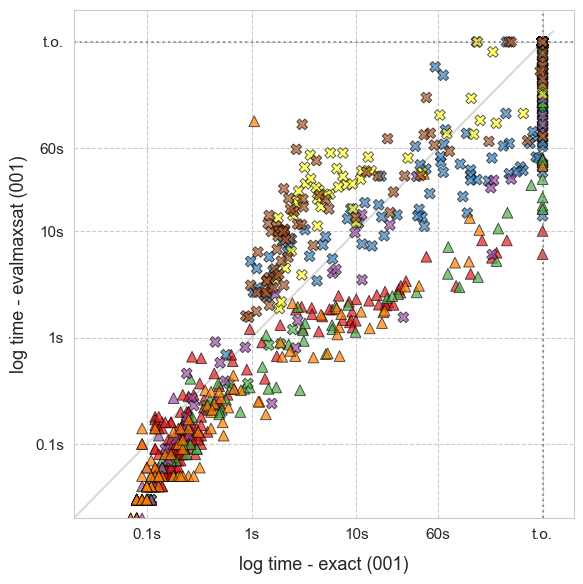

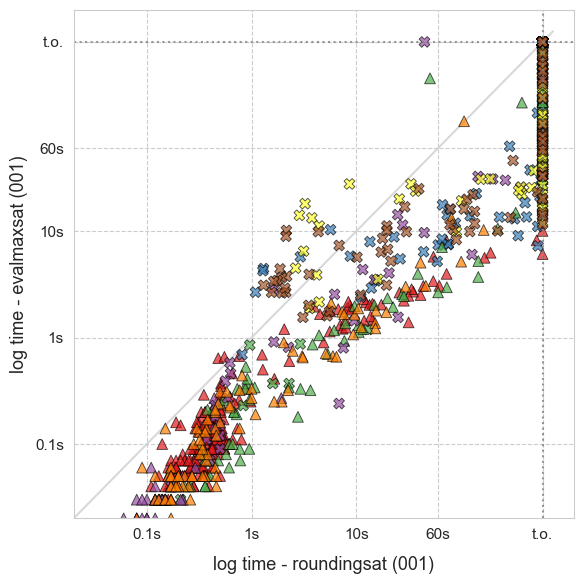

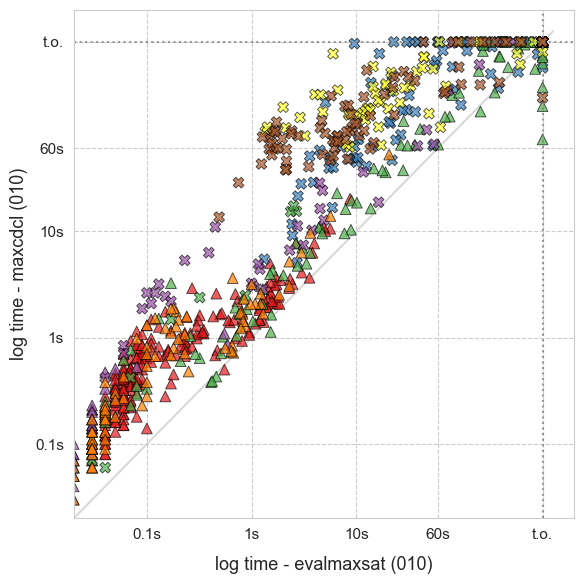

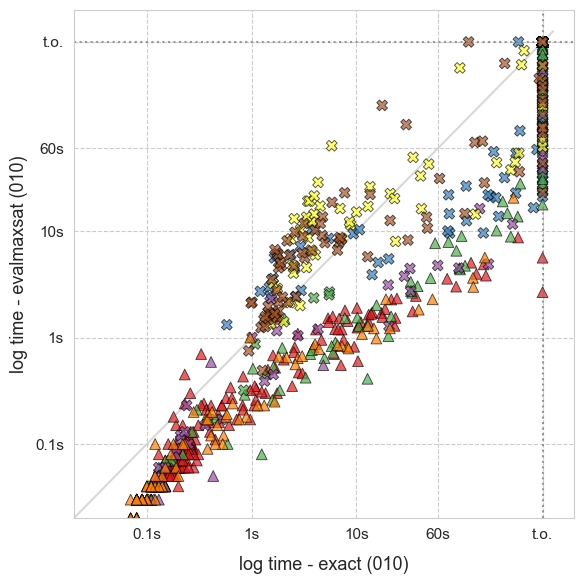

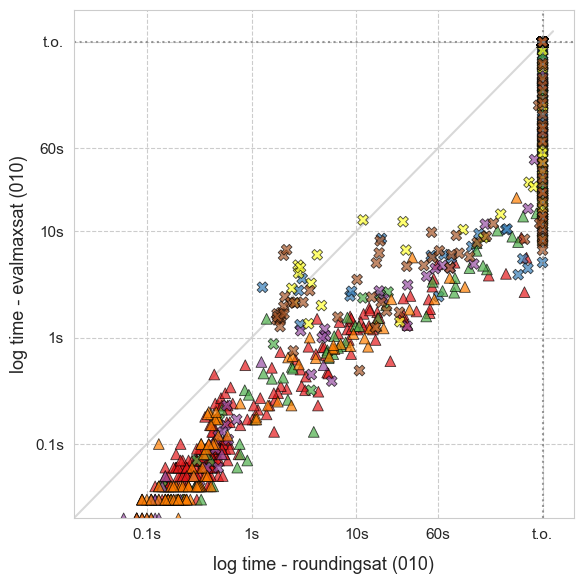

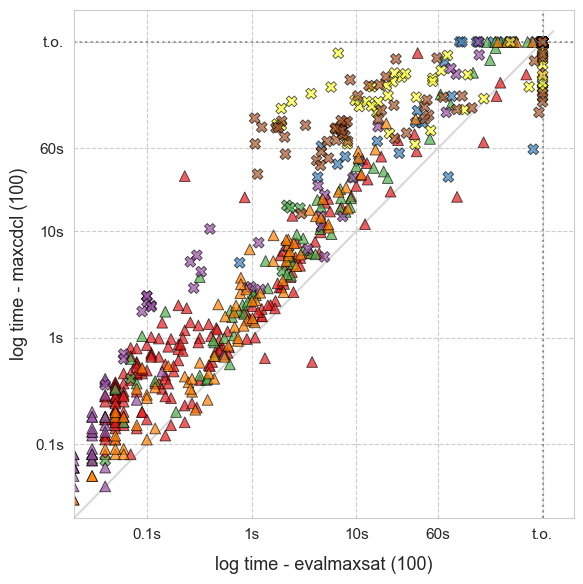

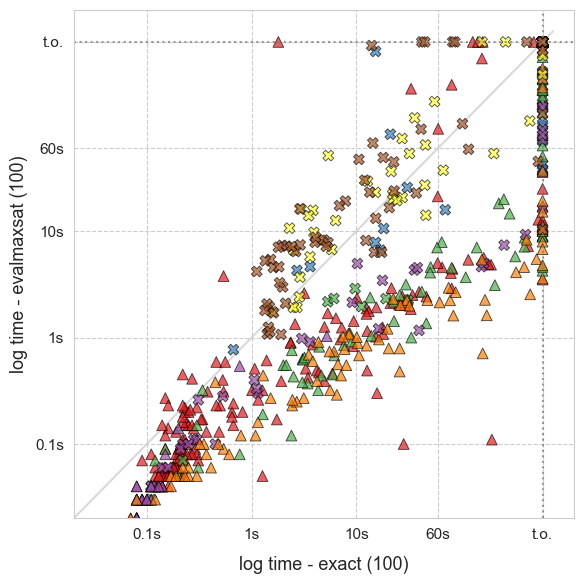

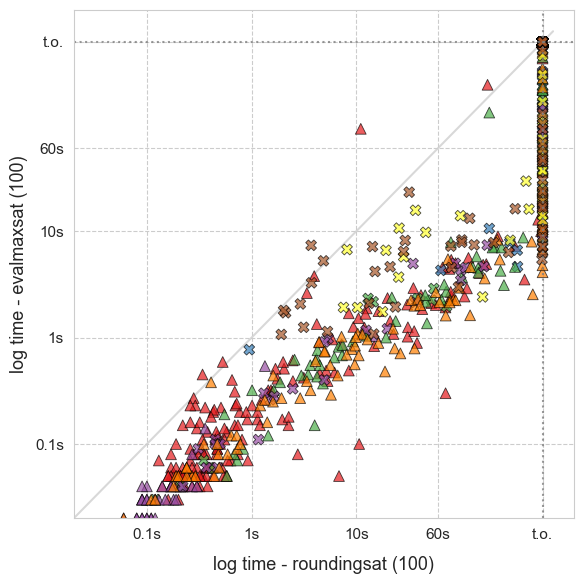

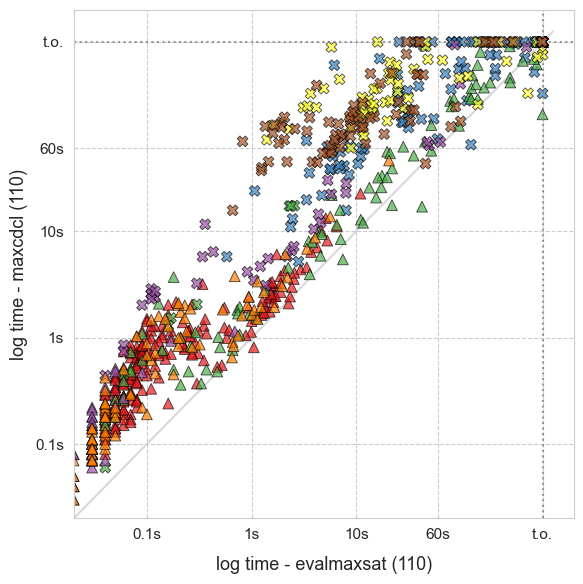

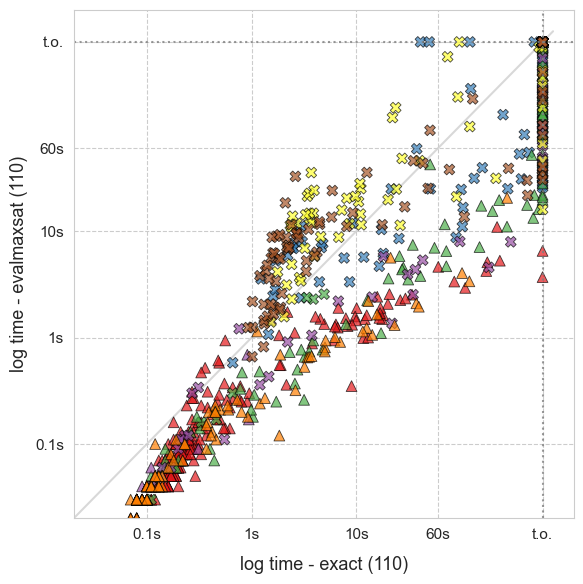

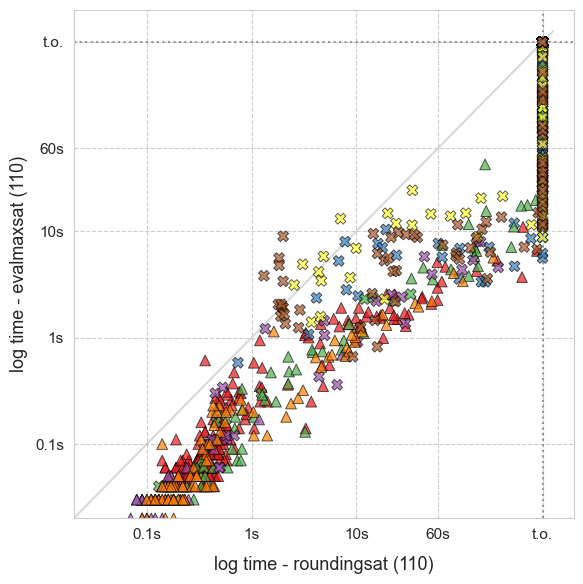

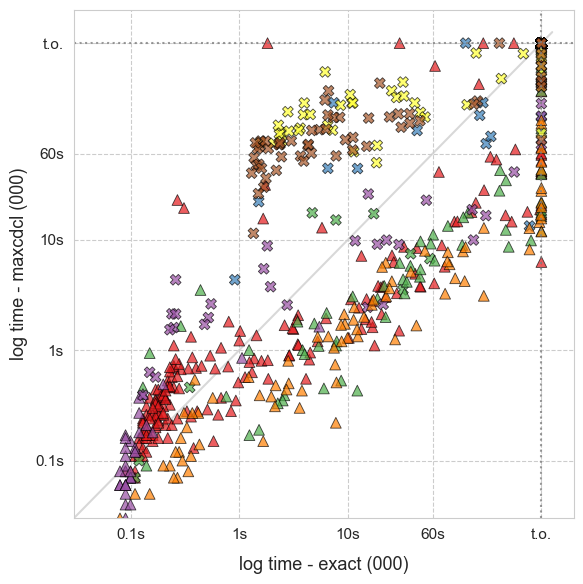

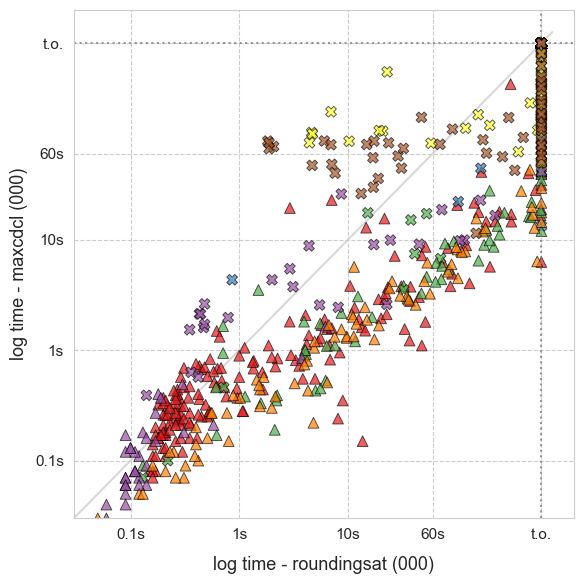

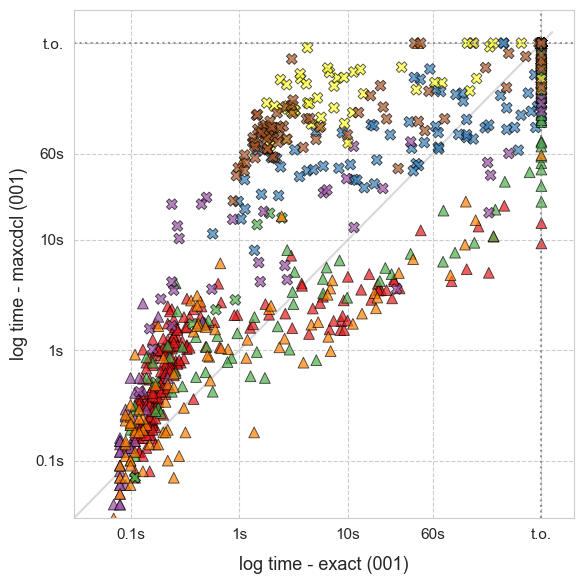

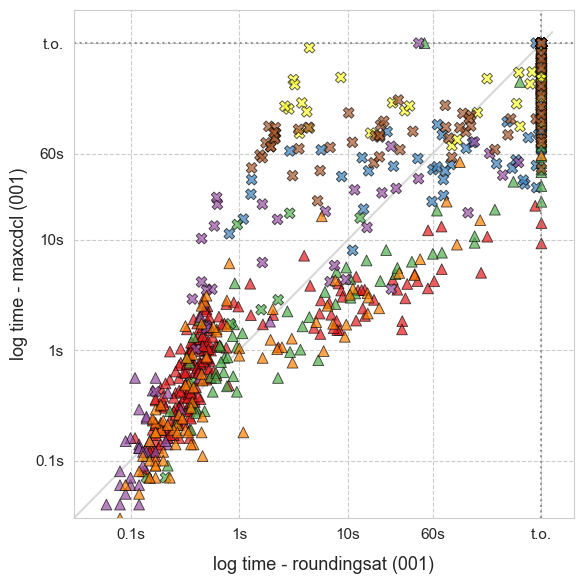

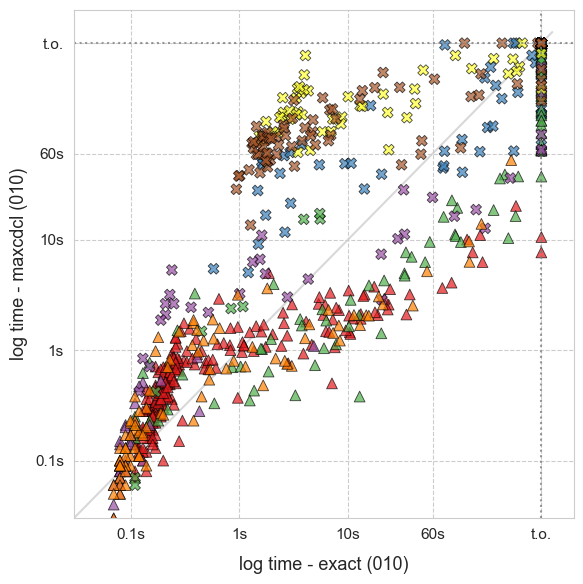

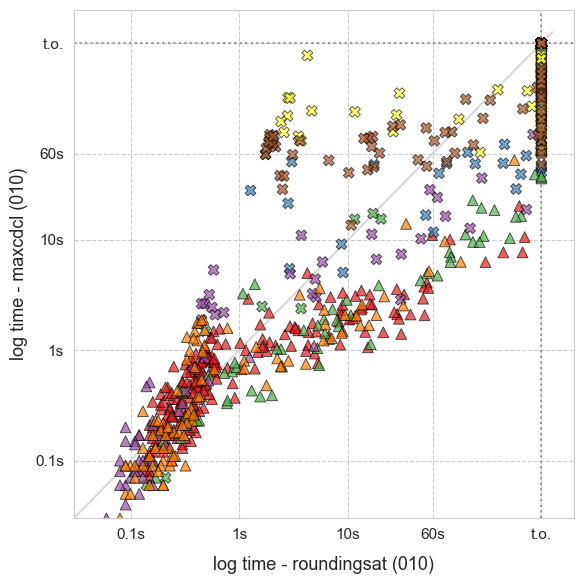

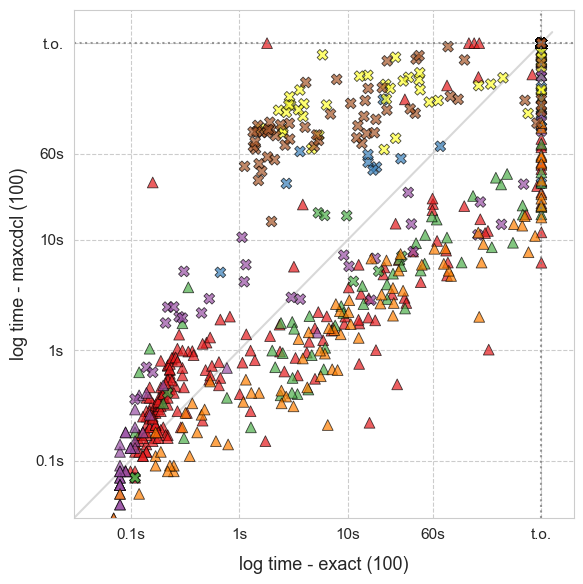

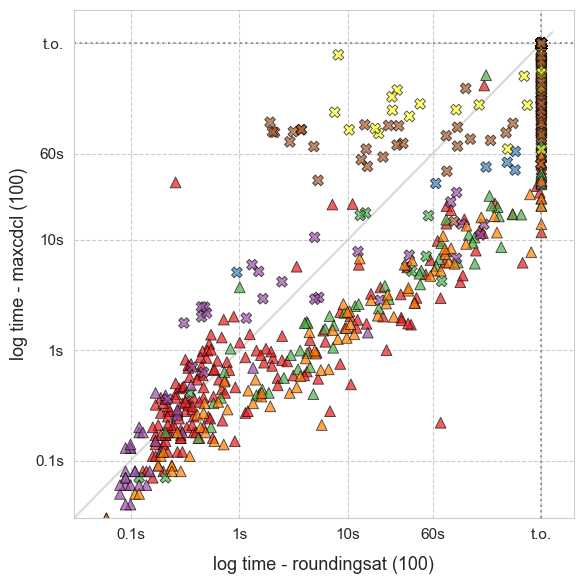

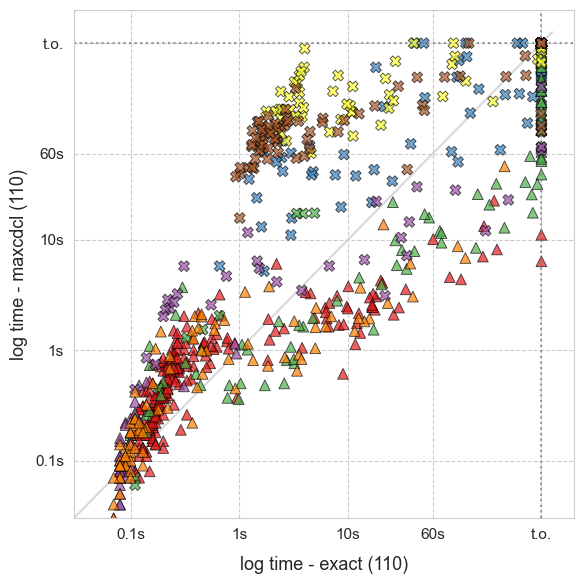

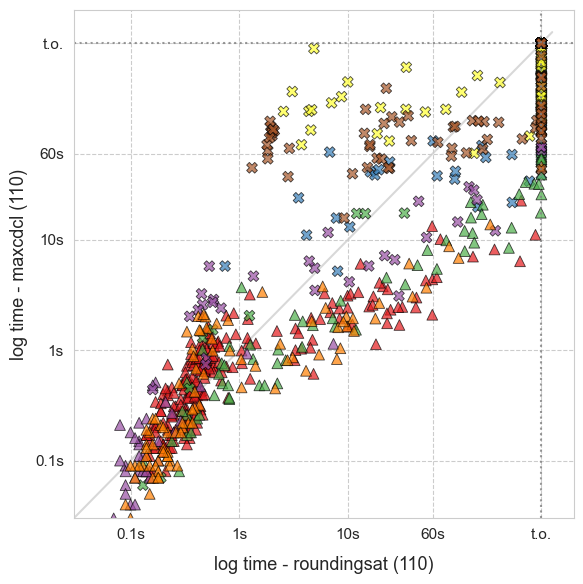

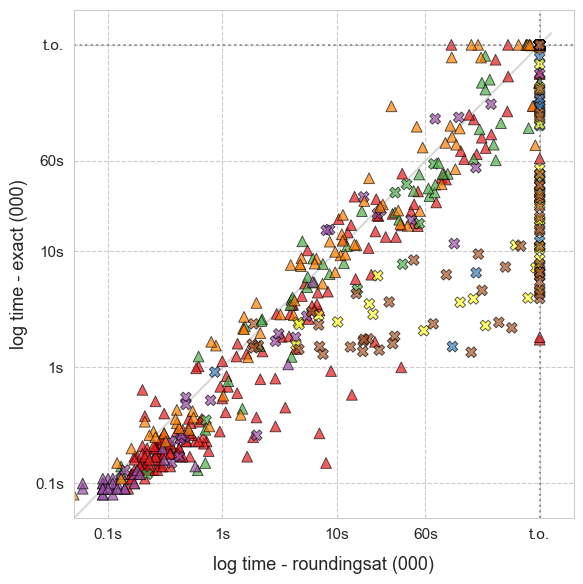

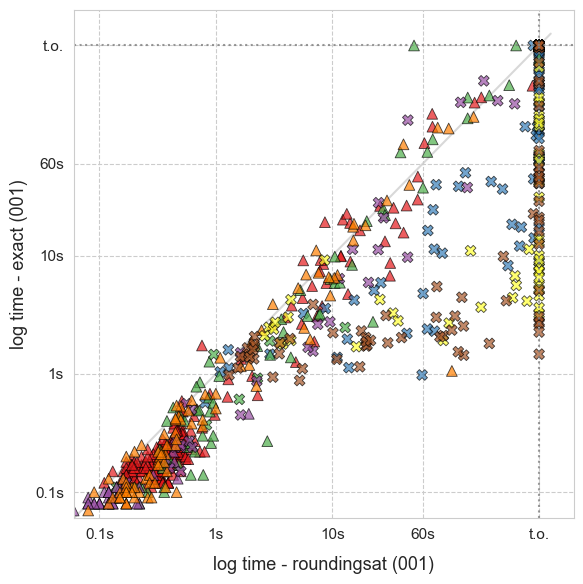

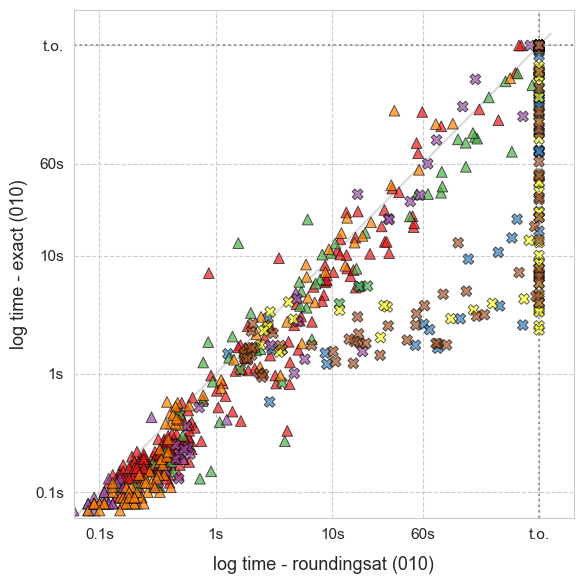

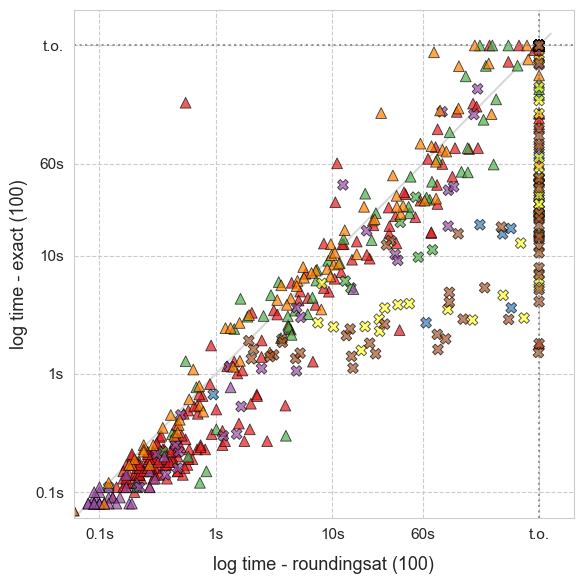

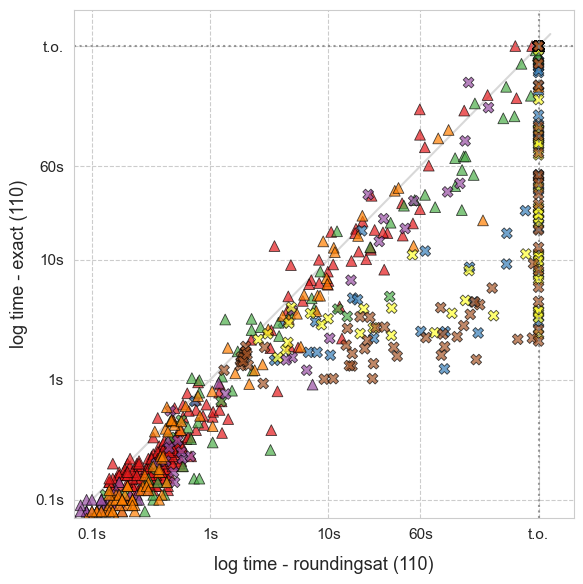

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os

# Academic paper settings
mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.autolayout": True,
    }
)

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.6})

timeout = 10
log10_timeout = np.log10(timeout * 60)
exported_shared_legend = True

for (experiment_a, experiment_b), implied_bitmask in pairs:
    if experiment_a == experiment_b:
        continue
    if "maxsat" in experiment_b:
        experiment_a, experiment_b = experiment_b, experiment_a

    metadata_a = metadata_name(experiment_a, trim=3)
    metadata_b = metadata_name(experiment_b, trim=3)
    axis_a_name, axis_b_name = metadata_a["axis"], metadata_b["axis"]

    exp_a = df_merged[df_merged["inline_config"] == experiment_a]
    exp_b = df_merged[df_merged["inline_config"] == experiment_b]
    df = pd.merge(exp_a, exp_b, on="mspsp_instance", suffixes=("_a", "_b"))

    df["activity_a"] = df["n_activities_a"].apply(
        lambda x: (
            f"<{median_activities}"
            if x < median_activities
            else f"≥{median_activities}"
        )
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    # Updated markers: Removed 'o' (circle), using 'D' (diamond) and 'X' (cross)
    markers_act = ["^", "X"]

    sns.scatterplot(
        data=df,
        y="solver.log_real_time_a",
        x="solver.log_real_time_b",
        hue="family_a",
        style="activity_a",
        markers=markers_act,
        alpha=0.7,
        edgecolor="black",
        s=60,
        palette="Set1",
        ax=ax,
        legend="brief",
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    # Lines and Ticks
    ax.axhline(y=log10_timeout, color="gray", linestyle=":", linewidth=1.5, alpha=0.8)
    ax.axvline(x=log10_timeout, color="gray", linestyle=":", linewidth=1.5, alpha=0.8)

    min_val = min(
        df["solver.log_real_time_a"].min(), df["solver.log_real_time_b"].min()
    )
    max_val = max(
        df["solver.log_real_time_a"].max(),
        df["solver.log_real_time_b"].max(),
        log10_timeout + 0.1,
    )
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="gray",
        linestyle="-",
        alpha=0.3,
        zorder=0,
    )

    ax.set_ylim(min_val, max_val + 0.2)
    ax.set_xlim(min_val, max_val + 0.2)

    human_times = [0.1, 1, 10, 60, 600]
    ticks = [np.log10(t) for t in human_times]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t}s" if t != 600 else "t.o." for t in human_times])
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t}s" if t != 600 else "t.o." for t in human_times])

    plt.ylabel(f"log time - {axis_a_name}", labelpad=5)
    plt.xlabel(f"log time - {axis_b_name}", labelpad=10)

    # Save Individual Plot
    out_dir = os.path.join(
        DIRS["figures"],
        "head-to-head",
        implied_bitmask,
        f"activities-{median_activities}",
    )
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(
        os.path.join(out_dir, f"{axis_a_name}_vs_{axis_b_name}_nolegend.pdf"),
        bbox_inches="tight",
    )

    # 2. STANDALONE LEGEND EXPORT (Structured in two lines)
    if exported_shared_legend:
        fig_leg = plt.figure(figsize=(10, 1.2))

        try:
            fam_idx = labels.index("family_a")
            act_idx = labels.index("activity_a")

            fam_handles = handles[fam_idx + 1 : act_idx]
            fam_labels = labels[fam_idx + 1 : act_idx]

            act_handles = handles[act_idx + 1 :]
            act_labels = labels[act_idx + 1 :]

            # First legend (left box)
            leg1 = fig_leg.legend(
                fam_handles,
                fam_labels,
                loc="center left",
                bbox_to_anchor=(0.0, 0.5),
                ncol=len(fam_labels),
                frameon=True,
            )

            # Second legend (right box)
            leg2 = fig_leg.legend(
                act_handles,
                act_labels,
                loc="center right",
                bbox_to_anchor=(1.0, 0.5),
                ncol=len(act_labels),
                frameon=True,
            )

            fig_leg.add_artist(leg1)

            fig_leg.savefig(
                os.path.join(out_dir, "shared_legend.pdf"),
                bbox_inches="tight",
            )

        except ValueError:
            print("Could not find specific labels in legend; check data column names.")

        plt.close(fig_leg)
        exported_shared_legend = True

    plt.show()

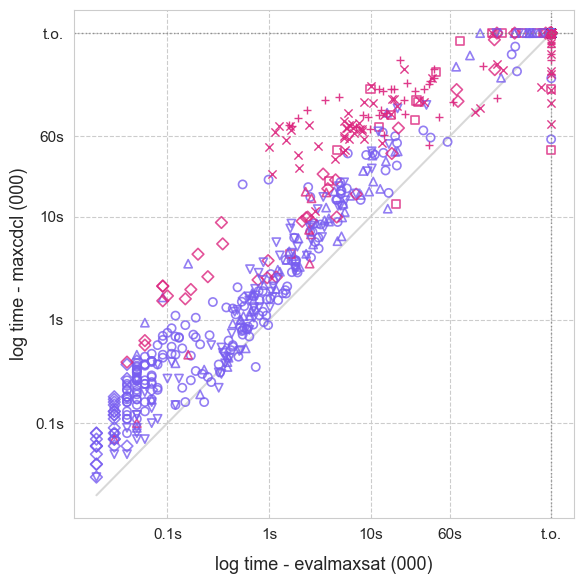

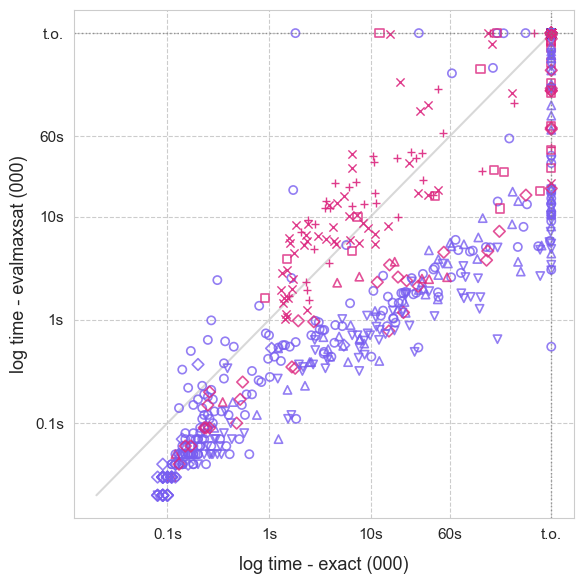

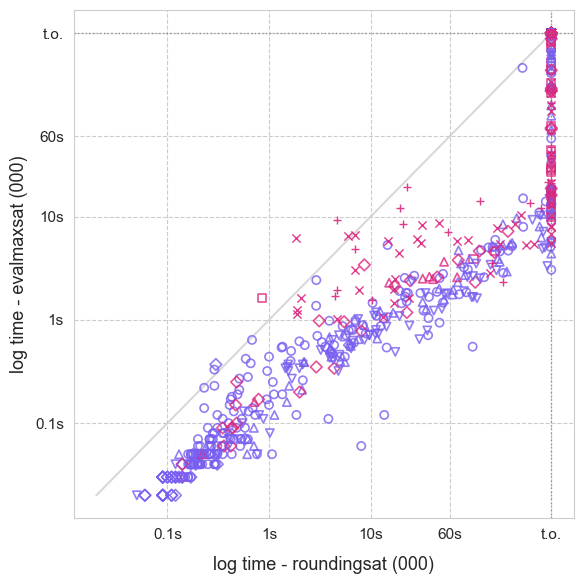

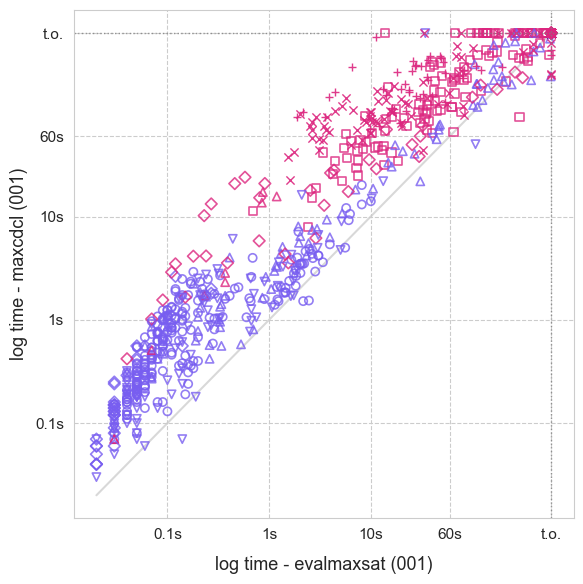

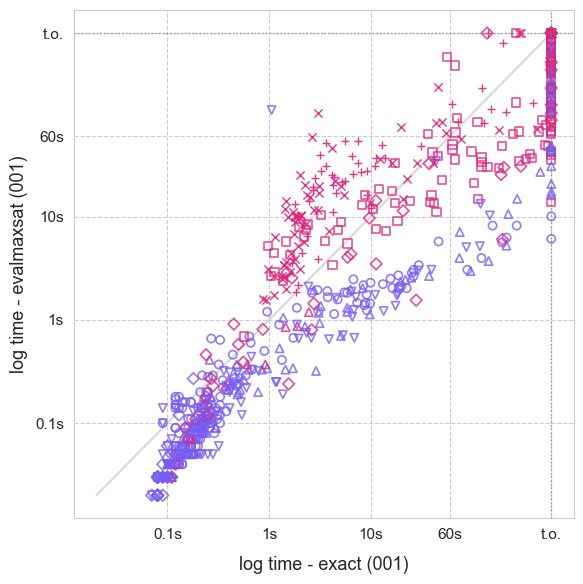

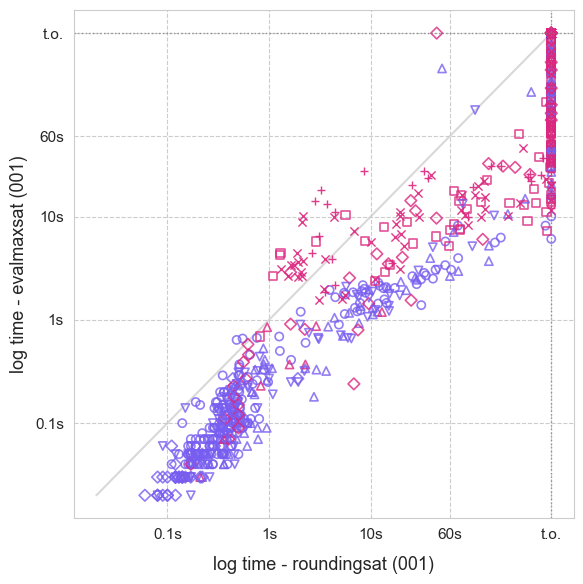

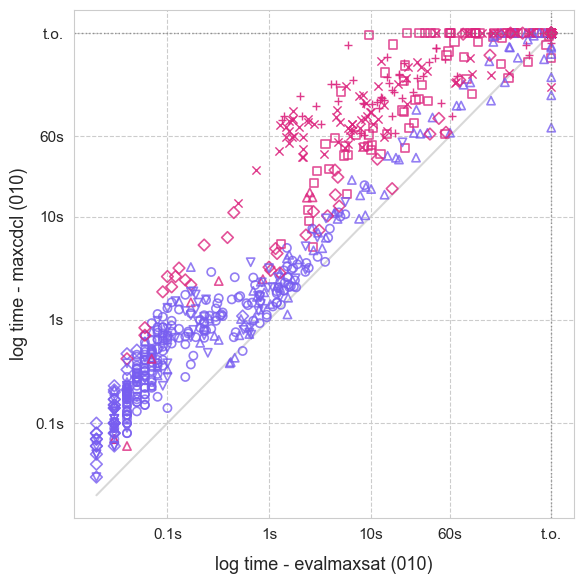

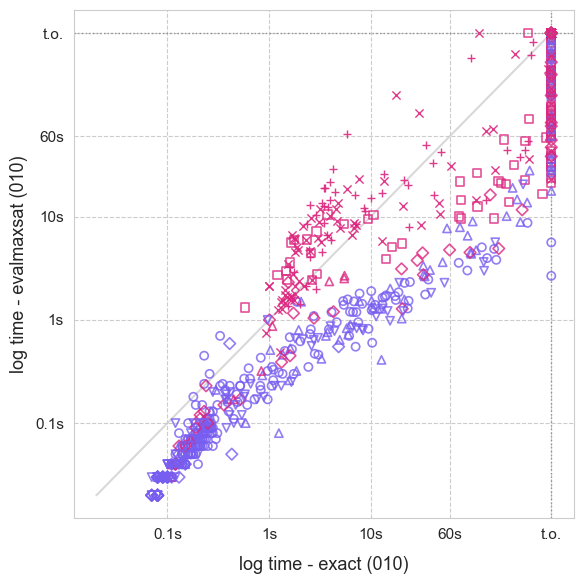

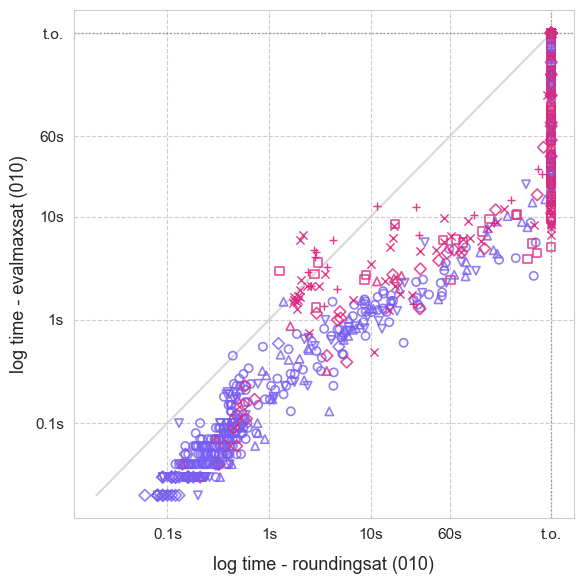

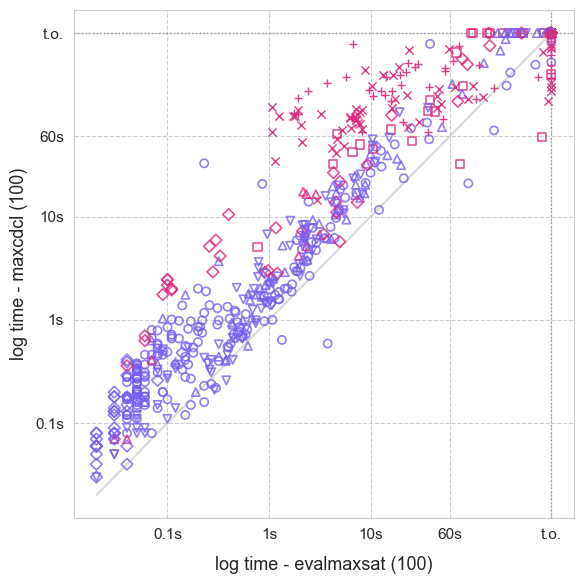

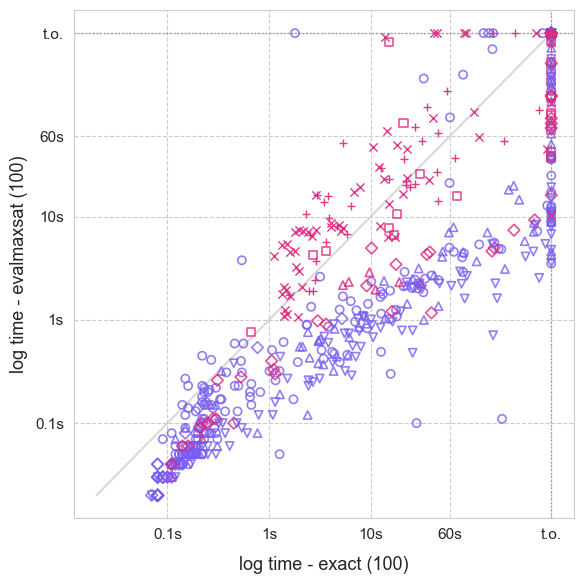

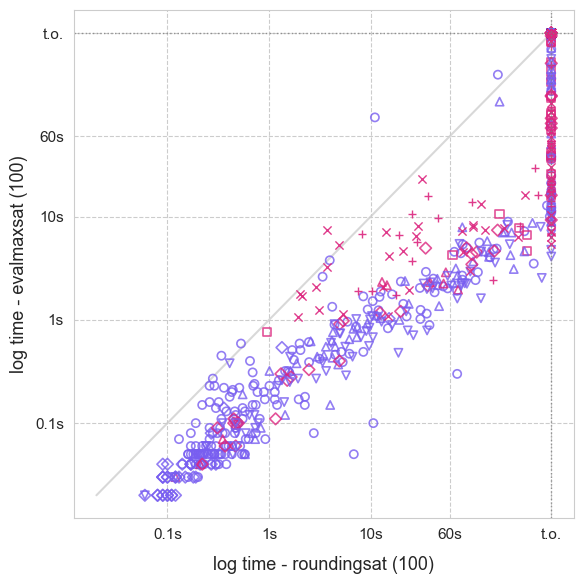

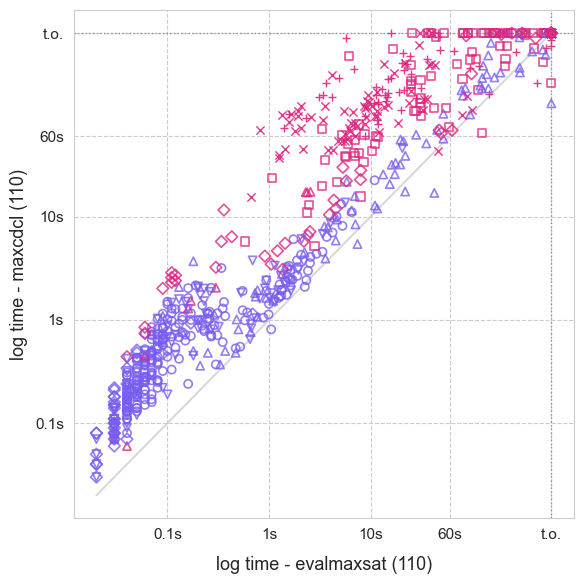

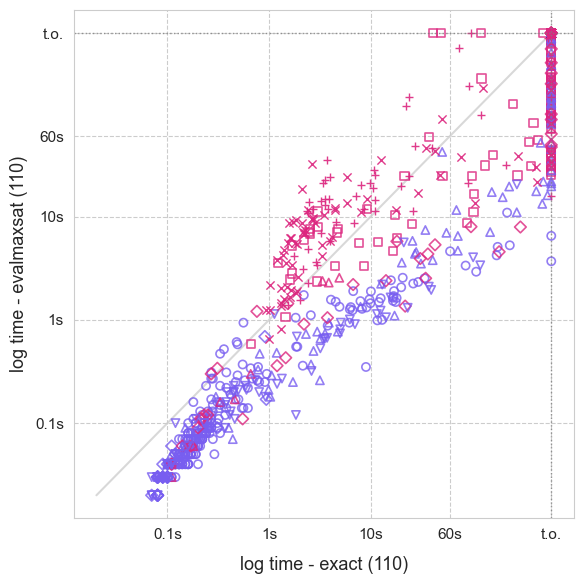

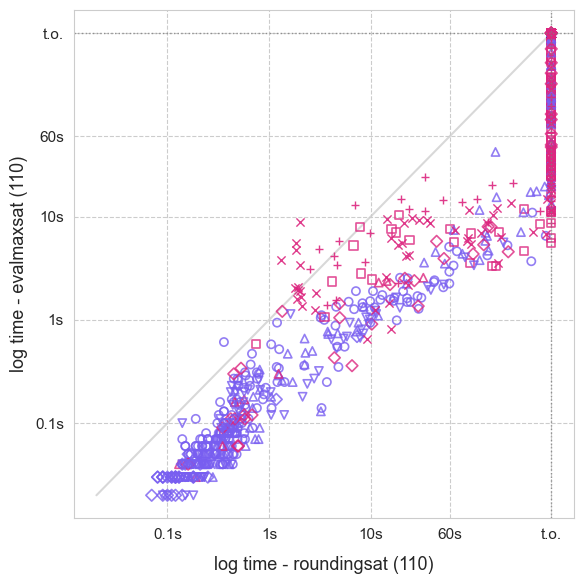

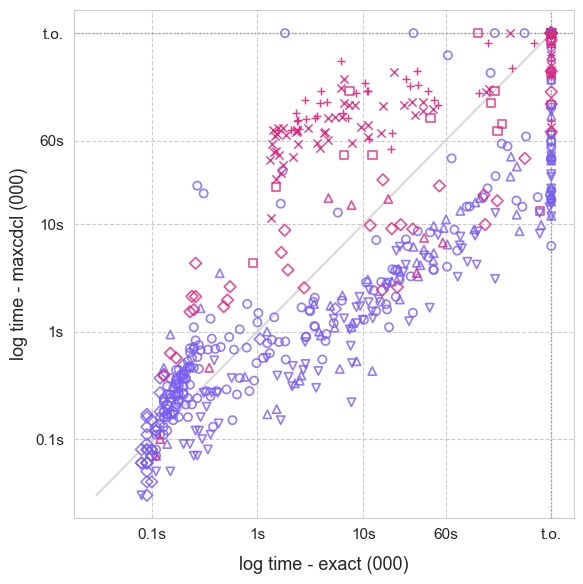

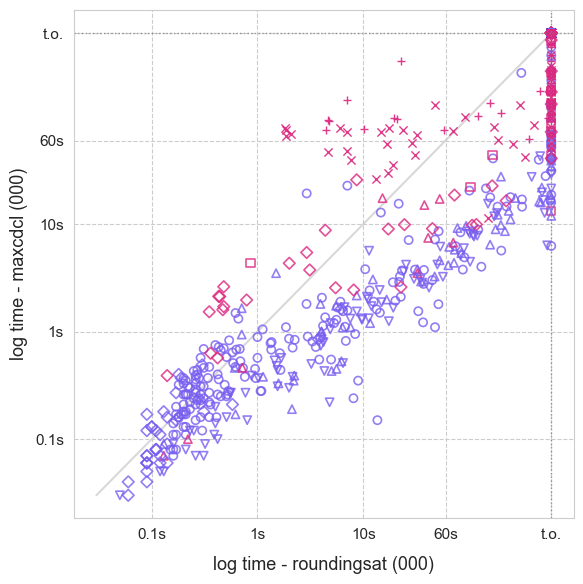

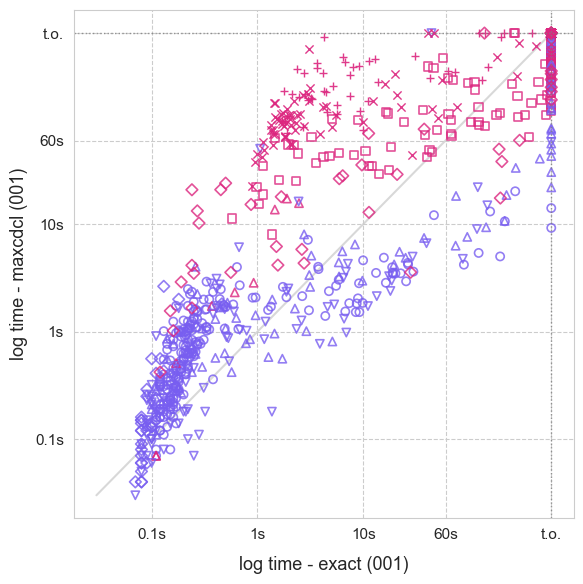

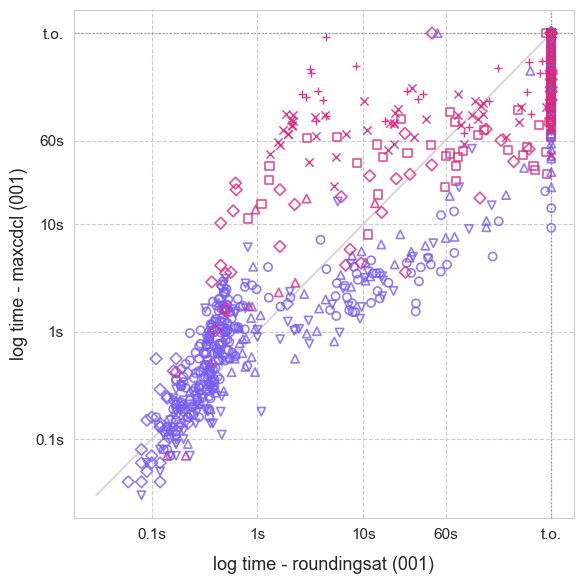

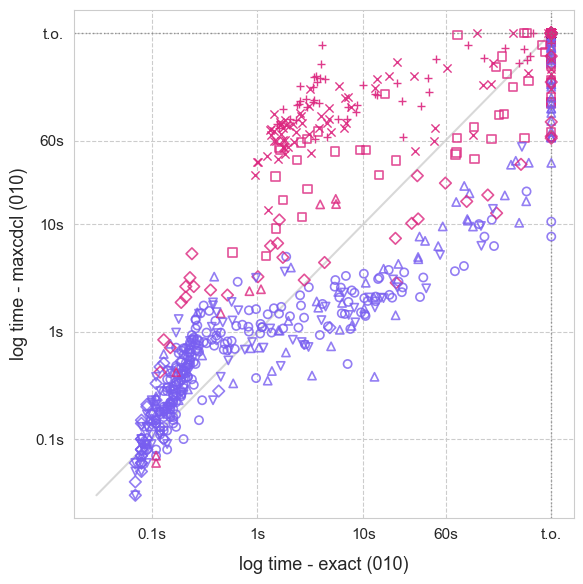

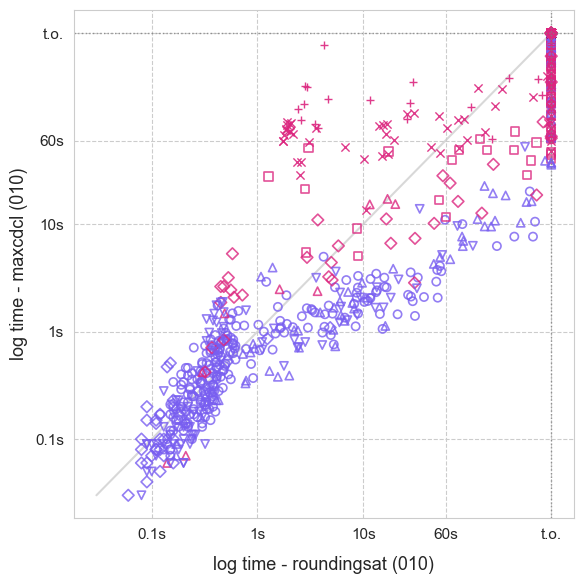

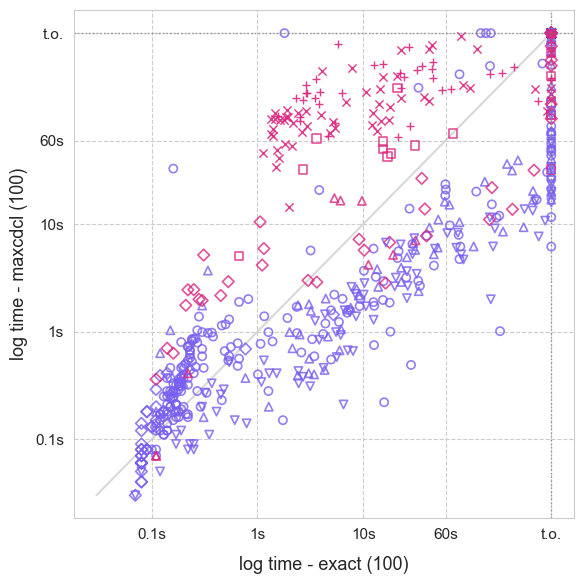

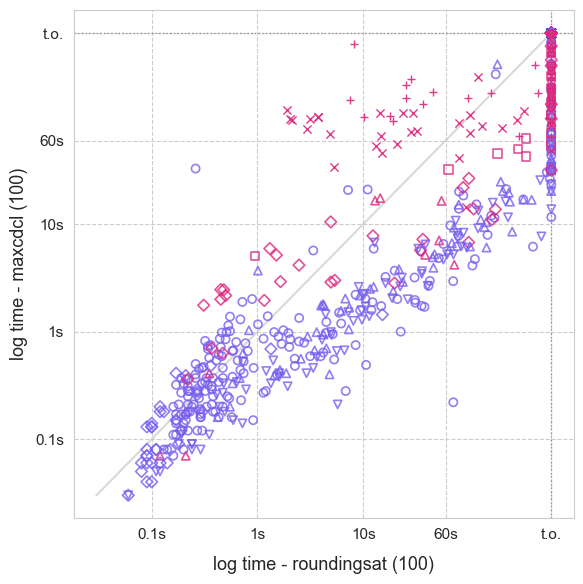

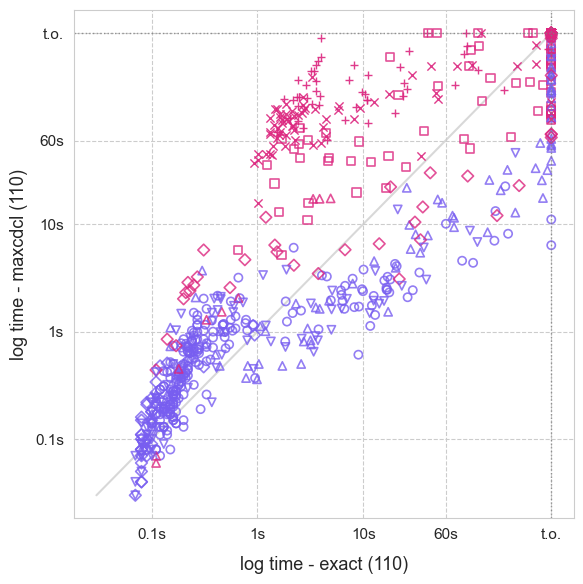

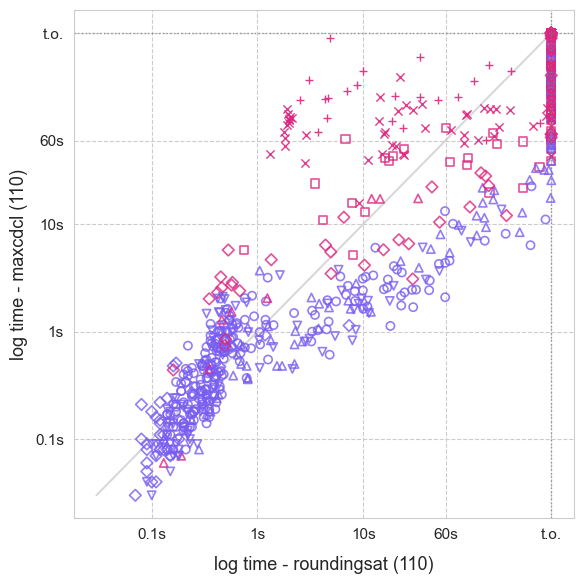

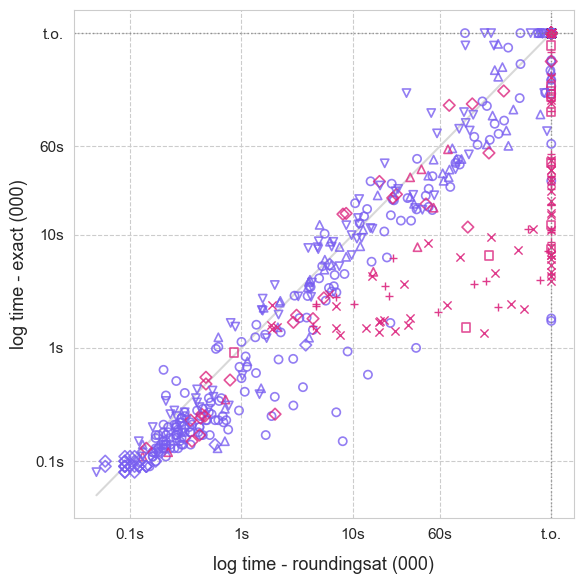

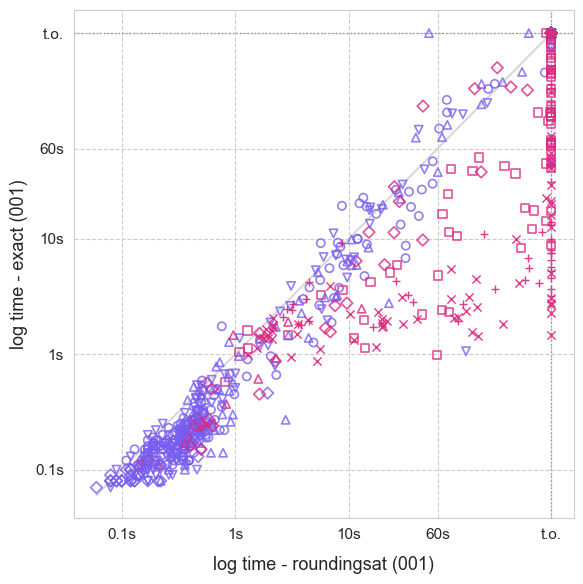

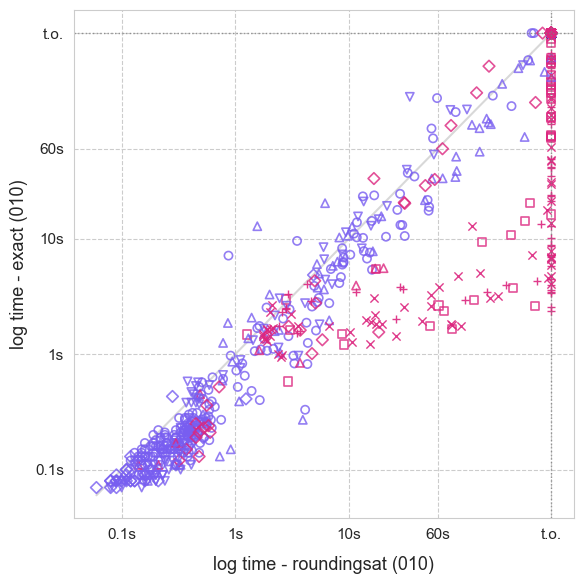

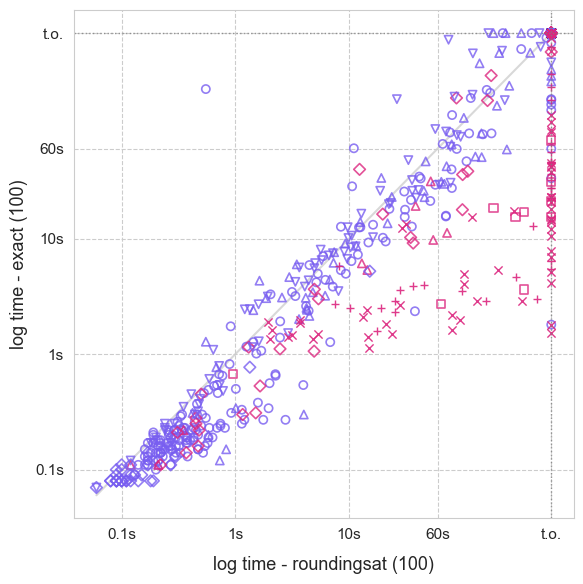

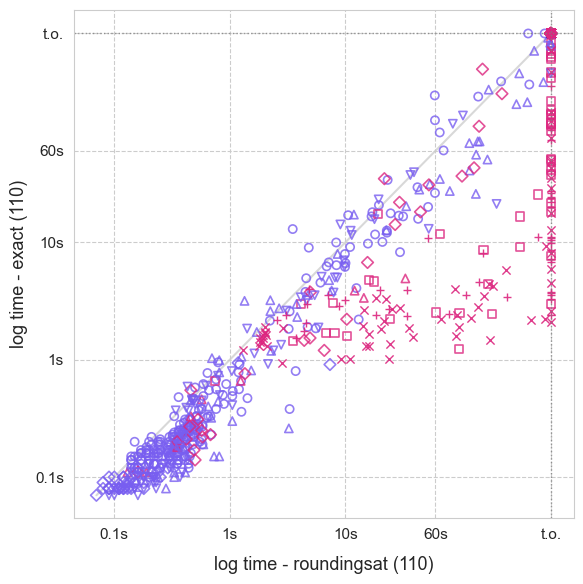

In [135]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os

# Academic paper settings
mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.autolayout": True,
    }
)

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.6})

activity_pallette = ["#785EF0", "#DC267F"]  # Deep Blue and Rich Orange

timeout = 10
log10_timeout = np.log10(timeout * 60)
# Flag to ensure we only export the legend once
exported_shared_legend = True

for (experiment_a, experiment_b), implied_bitmask in pairs:

    if experiment_a == experiment_b:
        continue

    if "maxsat" in experiment_b:
        experiment_a, experiment_b = experiment_b, experiment_a

    metadata_a = metadata_name(experiment_a, trim=3)
    metadata_b = metadata_name(experiment_b, trim=3)
    axis_a_name = metadata_a["axis"]
    axis_b_name = metadata_b["axis"]

    exp_a = df_merged[df_merged["inline_config"] == experiment_a]
    exp_b = df_merged[df_merged["inline_config"] == experiment_b]

    df = pd.merge(exp_a, exp_b, on="mspsp_instance", suffixes=("_a", "_b"))

    df["activity_a"] = df["n_activities_a"].apply(
        lambda x: (
            f"<{median_activities}"
            if x < median_activities
            else f"≥{median_activities}"
        )
    )

    # 1. Main Plot Figure (Slightly smaller/square is better for subfigures)
    fig, ax = plt.subplots(figsize=(6, 6))
    markers7 = ["o", "s", "^", "D", "v", "+", "x"]

    markers7 = ["o", "s", "^", "D", "v", "+", "x"]
    families = list(df["family_a"].unique())
    activities = list(df["activity_a"].unique())

    for i, fam in enumerate(families):
        for j, act in enumerate(activities):
            subdf = df[(df["family_a"] == fam) & (df["activity_a"] == act)]

            marker = markers7[i % len(markers7)]
            color = activity_pallette[j]

            if marker in ["+", "x"]:
                ax.scatter(
                    subdf["solver.log_real_time_b"],
                    subdf["solver.log_real_time_a"],
                    marker=marker,
                    c=[color],
                    s=35,
                    linewidths=1.0,
                    alpha=0.9,
                    label=None,
                )
            else:
                ax.scatter(
                    subdf["solver.log_real_time_b"],
                    subdf["solver.log_real_time_a"],
                    marker=marker,
                    facecolors="none",
                    edgecolors=[color],  # 👈 color now encodes activity
                    s=35,
                    linewidths=1.2,
                    alpha=0.8,
                    label=None,
                )

    # Lines and Ticks
    plt.axhline(y=log10_timeout, color="gray", linestyle=":", linewidth=1, alpha=0.8)
    plt.axvline(x=log10_timeout, color="gray", linestyle=":", linewidth=1, alpha=0.8)

    min_val = min(
        df["solver.log_real_time_a"].min(), df["solver.log_real_time_b"].min()
    )
    max_val = max(
        df["solver.log_real_time_a"].max(), df["solver.log_real_time_b"].max()
    )
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="gray",
        linestyle="-",
        alpha=0.3,
        zorder=0,
    )

    ymin, ymax = ax.get_ylim()
    ymax = max(ymax, log10_timeout + 0.2)
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(ymin, ymax)

    human_times = [0.1, 1, 10, 60, 600]
    ticks = [np.log10(t) for t in human_times]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t}s" if t != 600 else "t.o." for t in human_times])
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t}s" if t != 600 else "t.o." for t in human_times])

    plt.ylabel(f"log time - {axis_a_name}", labelpad=5)
    plt.xlabel(f"log time - {axis_b_name}", labelpad=10)

    # Save Individual Plot
    out_dir = os.path.join(
        DIRS["figures"],
        "head-to-head",
        implied_bitmask,
        f"activities-{median_activities}",
    )
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(
        os.path.join(out_dir, f"{axis_a_name}_vs_{axis_b_name}_nolegend.pdf"),
        bbox_inches="tight",
    )

    # 2. STANDALONE LEGEND EXPORT (Run once)
    if exported_shared_legend:
        legend_elements = []

        for i, fam in enumerate(families):
            marker = markers7[i % len(markers7)]

            if marker in ["+", "x"]:
                legend_elements.append(
                    Line2D(
                        [0],
                        [0],
                        marker=marker,
                        color="black",
                        linestyle="None",
                        markersize=6,
                        label=fam,
                    )
                )
            else:
                legend_elements.append(
                    Line2D(
                        [0],
                        [0],
                        marker=marker,
                        markerfacecolor="none",
                        markeredgecolor="black",
                        linestyle="None",
                        markersize=6,
                        label=fam,
                    )
                )

        # Get handles/labels before removing legend
        handles, labels = ax.get_legend_handles_labels()

        # Create a tiny figure just for the legend
        fig_leg = plt.figure(figsize=(12, 0.5))

        # Draw legend horizontally (ncol=... adjust based on how many markers you have)
        fig_leg.legend(
            handles=legend_elements,
            labels=[e.get_label() for e in legend_elements],
            loc="center",
            ncol=len(legend_elements),
            frameon=True,
            edgecolor="gray",
        )

        fig_leg.savefig(os.path.join(out_dir, "shared_legend.pdf"), bbox_inches="tight")
        plt.close(fig_leg)
        exported_shared_legend = True

    plt.show()